### k means clustering

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load data
df_feat = pd.read_csv('ipl_features.csv')

# chosing columns to cluster on
cluster_columns = ['win_by_runs', 'win_by_wickets']
X_cluster = df_feat[cluster_columns].fillna(0)

# scaling data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)



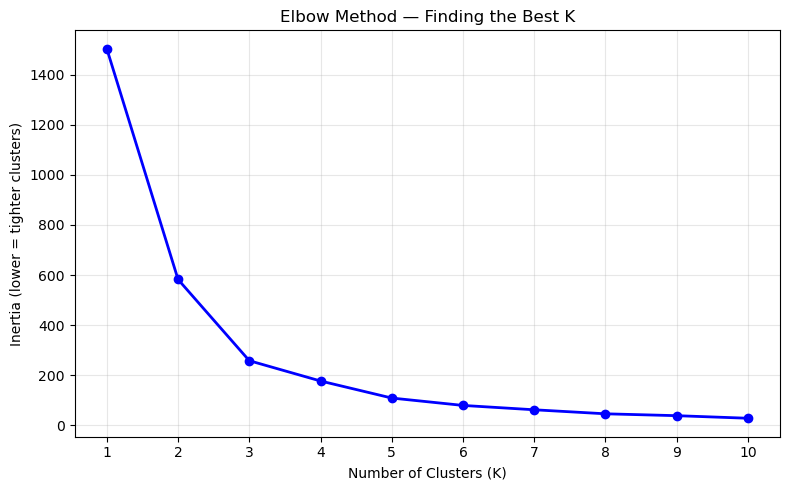

In [3]:

# elbow method to find the best value of k

inertias = []
k_values = range(1, 11)   # try K from 1 to 10

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='blue', linewidth=2)
plt.title('Elbow Method — Finding the Best K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [4]:
#training wiht k=3
BEST_K = 3 #Based on elbow chart, K=3 

final_km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_feat['cluster'] = final_km.fit_predict(X_scaled)

print(f"\nK-Means trained with K={BEST_K}")
print("\nCluster sizes:")
print(df_feat['cluster'].value_counts())




K-Means trained with K=3

Cluster sizes:
cluster
1    397
0    302
2     53
Name: count, dtype: int64
